# Remote COPC Access in R with lasR 0.20.0 — via GDAL VSI
## Using MAAP `GEDI_CalVal_Lidar_COPC` Collection

> **Release:** lasR 0.20.0 — now on [r-universe](https://r-lidar.r-universe.dev)  
> **Feature:** Remote COPC read via GDAL VSI (`/vsicurl/`, `/vsis3/`)  
> **Reference:** [r-lidar/lasR#278](https://github.com/r-lidar/lasR/issues/278)  
> **Data:** [MAAP GEDI CalVal Lidar COPC](https://stac-browser.maap-project.org/collections/GEDI_CalVal_Lidar_COPC) — `s3://nasa-maap-data-store`  
> **Environment:** MAAP Hub — R `pyrocket-geospatial` workspace only

> ⚠️ **Note:** This notebook is designed to run exclusively on the [MAAP Hub](https://hub.maap-project.org) 
> in the **R `pyrocket-geospatial` workspace**. It requires access to the `s3://nasa-maap-data-store` 
> bucket and the conda GDAL libraries pre-installed in that environment. 
> Running outside the MAAP Hub will require additional configuration.

## Background

**lasR 0.20.0** is the first production release with remote COPC support via GDAL's Virtual 
Filesystem (VSI) layer. Any URL or cloud URI that GDAL can range-read — `https://`, `s3://`, 
Azure ADLS — can now be passed directly to `reader_las()` and its spatial variants without 
downloading the file first.

This notebook demonstrates the feature using the **MAAP `GEDI_CalVal_Lidar_COPC`** collection —
airborne LiDAR point clouds at GEDI calibration/validation sites, stored as `.copc.laz` files 
on `s3://nasa-maap-data-store`. 

## What this notebook covers

| Section | Description |
|---|---|
| 1 | Install lasR 0.20.0 + environment setup |
| 2 | STAC discovery — enumerate COPC items from MAAP catalogue |
| 3a | Header read — metadata without downloading the file |
| 3b | Spatial filtering — bbox and circle queries on remote COPC |
| 4 | Derived products — DTM and CHM from a remote COPC tile |
| 5 | Multi-file catalogue — process multiple remote tiles |

### Installation and Setup

In [1]:
# Install lasR 0.20.0 (released) + environment setup
library(lasR)
cat("lasR version:", as.character(packageVersion("lasR")), "\n")
cat("lasR loaded OK\n")

# VSI / S3 environment variables
Sys.setenv(
  AWS_NO_SIGN_REQUEST                = "YES",
  GDAL_HTTP_MERGE_CONSECUTIVE_RANGES = "YES",
  CPL_VSIL_CURL_CHUNK_SIZE           = "1048576",
  CPL_VSIL_CURL_CACHE_SIZE           = "67108864",
  GDAL_HTTP_CONNECTTIMEOUT           = "30",
  GDAL_HTTP_TIMEOUT                  = "120"
)
cat("VSI environment variables set\n")

lasR version: 0.20.0 
lasR loaded OK
VSI environment variables set


In [2]:
# ── Cell 1.2: Install/verify R package dependencies
pkgs <- c("remotes", "httr2", "jsonlite", "sf", "terra", "ggplot2", "dplyr")
missing <- pkgs[!sapply(pkgs, requireNamespace, quietly = TRUE)]
if (length(missing) > 0) {
  install.packages(missing, repos = "https://cloud.r-project.org")
}
cat("All R dependencies available\n")

All R dependencies available


### Reading External COPC File 

In [3]:
# Simple COPC access test using public Autzen Stadium file
library(lasR)

url <- "/vsicurl/https://s3.amazonaws.com/hobu-lidar/autzen-classified.copc.laz"

# Header only
pipeline <- reader_las(copc_depth = 0L) + summarise()
result   <- exec(pipeline, on = url)
print(result)

$npoints
[1] 61201

$nsingle
[1] 33483

$nwithheld
[1] 0

$nsynthetic
[1] 0

$npoints_per_return
    1     2     3     4 
50297  8816  1919   169 

$npoints_per_class
    0     2     5     6     9    15    17    19    64    65    66    68    73 
 2202 24096 29080  1667  3055    13    30   253   510   162     3    25   103 
   76    77 
    1     1 

$z_histogram
406.000000 408.000000 410.000000 412.000000 414.000000 416.000000 418.000000 
       511        451       1681        496        943       2768       2694 
420.000000 422.000000 424.000000 426.000000 428.000000 430.000000 432.000000 
      5109       4592       4979       3263       1722       1156       1109 
434.000000 436.000000 438.000000 440.000000 442.000000 444.000000 446.000000 
      1336       1525       1503       1244       1116       1229       1041 
448.000000 450.000000 452.000000 454.000000 456.000000 458.000000 460.000000 
       918        754       1187        976        803        735        912 
462.000000 

## STAC Discovery — Enumerate MAAP COPC Items

Query the MAAP STAC API to retrieve `.copc.laz` asset URLs from the `GEDI_CalVal_Lidar_COPC` collection.  
This mirrors what a user would do programmatically before passing URLs to lasR.

In [4]:
# ── Query MAAP STAC API using rstac
if (!requireNamespace("rstac", quietly = TRUE)) {
  install.packages("rstac", repos = "https://cloud.r-project.org")
}
library(rstac)

`%||%` <- function(a, b) if (!is.null(a)) a else b

STAC_API   <- "https://stac.maap-project.org"
COLLECTION <- "GEDI_CalVal_Lidar_COPC"

# Connect and fetch top 10 items
items <- stac(STAC_API) |>
  collections(COLLECTION) |>
  items(limit = 10) |>
  get_request()

cat(sprintf("Collection:     %s\n", COLLECTION))
cat(sprintf("Items returned: %d\n", length(items$features)))

# Extract IDs and asset HREFs
item_info <- lapply(items$features, function(feat) {
  assets <- feat$assets
  href   <- assets$data$href %||% assets$copc$href %||% assets[[1]]$href
  list(id = feat$id, href = href, bbox = feat$bbox)
})

# Build GDAL VSI URIs from S3 or HTTPS hrefs
build_vsi_uri <- function(href) {
  if (startsWith(href, "s3://"))        paste0("/vsis3/",    sub("^s3://",    "", href))
  else if (startsWith(href, "https://")) paste0("/vsicurl/", href)
  else href
}

ALL_URIS  <- vapply(item_info, function(it) build_vsi_uri(it$href), character(1))
test_item <- item_info[[1]]
TEST_URI  <- ALL_URIS[[1]]

cat("\n── Top 10 Items ──\n")
for (it in item_info) {
  cat(sprintf("  ID:  %s\n", it$id))
  cat(sprintf("  URI: %s\n\n", build_vsi_uri(it$href)))
}

Collection:     GEDI_CalVal_Lidar_COPC
Items returned: 10

── Top 10 Items ──
  ID:  usa_tepeecreek_2809704010602
  URI: /vsis3/nasa-maap-data-store/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809704010602.copc.laz

  ID:  usa_tepeecreek_2809702010602
  URI: /vsis3/nasa-maap-data-store/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809702010602.copc.laz

  ID:  usa_tepeecreek_2809700010602
  URI: /vsis3/nasa-maap-data-store/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809700010602.copc.laz

  ID:  usa_tepeecreek_2809698010602
  URI: /vsis3/nasa-maap-data-store/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809698010602.copc.laz

  ID:  usa_tepeecreek_2809696010602
  URI: /vsis3/nasa-maap-data-store/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809696010602.copc.laz

  ID:  usa_tepeecreek_2809694010602
  URI: /vsis3/nasa-maap-data-store/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809694010602.co

In [5]:
# ── Select test item — URIs already built from rstac query
test_item <- item_info[[1]]
TEST_URI  <- ALL_URIS[[1]]

cat("Test item selected:\n")
cat("  ID:  ", test_item$id, "\n")
cat("  URI: ", TEST_URI,     "\n")

Test item selected:
  ID:   usa_tepeecreek_2809704010602 
  URI:  /vsis3/nasa-maap-data-store/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809704010602.copc.laz 


## Partial Read Tests — lasR `devel` COPC/VSI

### 3a — Header Metadata Only (`copc_depth = 0`)

In [6]:
# ── Header-only read
library(lasR)

cat("Testing:", TEST_URI, "\n\n")

t0 <- proc.time()
result_header <- exec(reader_las(copc_depth = 0L) + summarise(), on = TEST_URI)
cat(sprintf("── Header read complete in %.1fs ──\n", (proc.time() - t0)["elapsed"]))
print(result_header)

# Extract projected CRS EPSG from PROJCS block in compound WKT
# $epsg returns 0 for compound CRS (COMPD_CS) — known lasR 0.20.0 issue
wkt          <- result_header$crs
projcs_block <- sub(".*?(PROJCS\\[.*?\\]),VERT_CS.*", "\\1", wkt, perl = TRUE)
epsg_hits    <- regmatches(projcs_block,
                            gregexpr('(?<=AUTHORITY\\["EPSG",")\\d+(?="\\])',
                                     projcs_block, perl = TRUE))[[1]]
TILE_EPSG    <- as.integer(tail(epsg_hits, 1))
cat(sprintf("\n✅ Projected CRS EPSG: %d — %s\n", TILE_EPSG, sf::st_crs(TILE_EPSG)$Name))

Testing: /vsis3/nasa-maap-data-store/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809704010602.copc.laz 

── Header read complete in 0.4s ──
$npoints
[1] 79321

$nsingle
[1] 31321

$nwithheld
[1] 0

$nsynthetic
[1] 0

$npoints_per_return
    1     2     3     4     5     6     7 
52327 19565  5977  1326   119     6     1 

$npoints_per_class
    1     2 
61277 18044 

$z_histogram
1360.000000 1362.000000 1364.000000 1366.000000 1368.000000 1370.000000 
         10          58          62         142         247         263 
1372.000000 1374.000000 1376.000000 1378.000000 1380.000000 1382.000000 
        422         596         587         768         927         788 
1384.000000 1386.000000 1388.000000 1390.000000 1392.000000 1394.000000 
       1113        1151        1098        1443        1745        1555 
1396.000000 1398.000000 1400.000000 1402.000000 1404.000000 1406.000000 
       1989        2055        1880        2333        2267        2127 
1408.000000 1410

### Cell 3b — Spatial Filtering: COPC Partial Read Proof of Concept (new)

In [12]:
library(lasR)

url <- "/vsis3/nasa-maap-data-store/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809704010602.copc.laz"

# 1. Full file — how many points total?
full  <- exec(reader_las() + summarise(), on = url)
cat("Total points in file:  ", format(full$npoints, big.mark = ","), "\n")

# 2. Spatial subset — read only a 300 x 300 m window
# Coordinates in the file's native CRS (NAD83 HARN / UTM zone 11N, metres)
subset <- lasR::exec(
  reader_las_rectangles(
    xmin = 558600, ymin = 5295200,
    xmax = 558900, ymax = 5295500
  ) + summarise(),
  on = url
)
cat("Points in 300x300m window:", format(subset$npoints, big.mark = ","), "\n")
cat("Fraction of file read:     ", 
    sprintf("%.1f%%\n", 100 * subset$npoints / full$npoints))

# 3. Confirm partial read worked
if (subset$npoints > 0 && subset$npoints < full$npoints) {
  cat("\n✅ COPC spatial filtering works — only a subset of the file was read\n")
}

Total points in file:   2,570,977 
Points in 300x300m window: 1,409,855 
Fraction of file read:      54.8%

✅ COPC spatial filtering works — only a subset of the file was read


## Derived Products from MAAP COPC

### 4a — Digital Terrain Model

terra 1.8.70


Compiled with:3.12.1-CAPI-1.18.1

 Running with:3.13.1-CAPI-1.19.2


You should reinstall package 'terra'



Attaching package: ‘terra’


The following objects are masked from ‘package:lasR’:

    focal, rasterize




Computing DTM from remote COPC...
Output: /tmp/RtmpS4cpcH/usa_tepeecreek_2809704010602_dtm.tif 



class       : SpatRaster 
size        : 290, 301, 1  (nrow, ncol, nlyr)
resolution  : 1, 1  (x, y)
extent      : 558600, 558901, 5295211, 5295501  (xmin, xmax, ymin, ymax)
coord. ref. : NAD83(HARN) / UTM zone 11N (EPSG:3741) 
source      : usa_tepeecreek_2809704010602_dtm.tif 
name        : max 


DTM completed in 2.8s
class       : SpatRaster 
size        : 289, 300, 1  (nrow, ncol, nlyr)
resolution  : 1, 1  (x, y)
extent      : 558600, 558900, 5295211, 5295500  (xmin, xmax, ymin, ymax)
coord. ref. : NAD83(HARN) / UTM zone 11N (EPSG:3741) 
source(s)   : memory
varname     : usa_tepeecreek_2809704010602_dtm 
name        :     max 
min value   : 1361.23 
max value   : 1488.53 


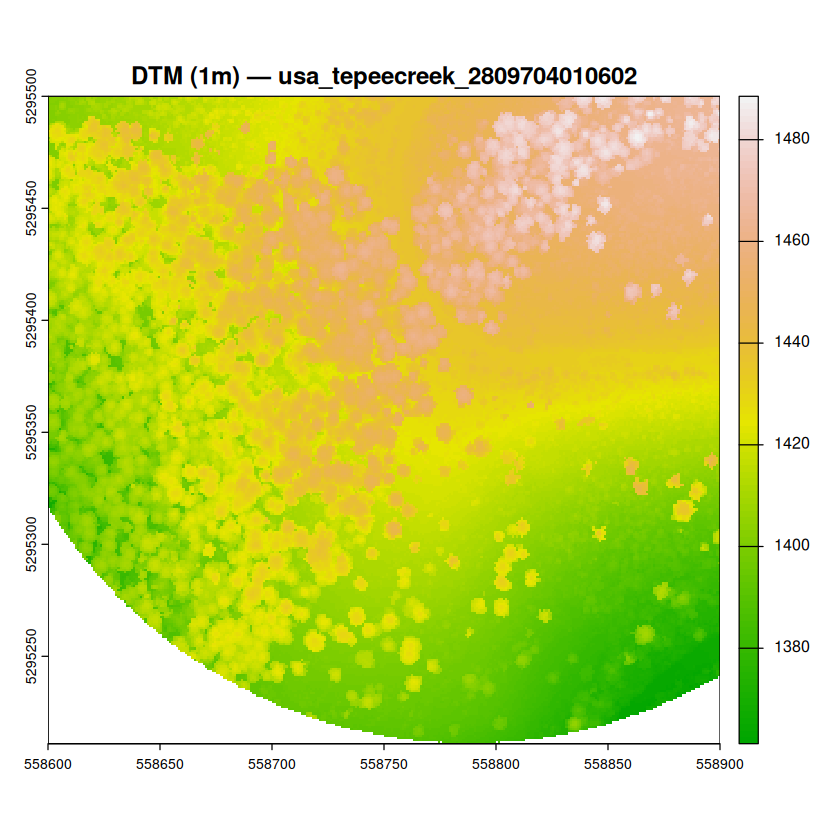

In [8]:
# ── Cell 4.1: DTM from remote MAAP GEDI CalVal COPC tile
library(lasR)
library(terra)

# Same 300x300m window as the spatial filtering demo
XMIN <- 558600; XMAX <- 558900
YMIN <- 5295200; YMAX <- 5295500

dtm_out <- file.path(tempdir(), paste0(test_item$id, "_dtm.tif"))
cat("Computing DTM from remote COPC...\nOutput:", dtm_out, "\n\n")

t0 <- proc.time()
pipeline_dtm <- reader_las_rectangles(
    xmin = XMIN, ymin = YMIN,
    xmax = XMAX, ymax = YMAX,
    copc_depth = NULL
  ) +
  triangulate(filter = keep_ground()) +
  lasR::rasterize(res = 1, method = "tin", ofile = dtm_out)

exec(pipeline_dtm, on = TEST_URI)
cat(sprintf("\nDTM completed in %.1fs\n", (proc.time() - t0)["elapsed"]))

if (file.exists(dtm_out)) {
  dtm <- terra::rast(dtm_out)
  dtm <- terra::crop(dtm, terra::ext(XMIN, XMAX, YMIN, YMAX))
  print(dtm)
  terra::plot(dtm,
              main   = paste0("DTM (1m) — ", test_item$id),
              col    = terrain.colors(100),
              axes   = TRUE,
              legend = TRUE)
}

### 4b — Canopy Height Model

Computing CHM from remote COPC...
Output: /tmp/RtmpS4cpcH/usa_tepeecreek_2809704010602_chm.tif 



class       : SpatRaster 
size        : 578, 601, 1  (nrow, ncol, nlyr)
resolution  : 0.5, 0.5  (x, y)
extent      : 558600, 558900.5, 5295212, 5295500  (xmin, xmax, ymin, ymax)
coord. ref. : NAD83(HARN) / UTM zone 11N (EPSG:3741) 
source      : usa_tepeecreek_2809704010602_chm.tif 
name        : max 


CHM completed in 3.9s
class       : SpatRaster 
size        : 577, 600, 1  (nrow, ncol, nlyr)
resolution  : 0.5, 0.5  (x, y)
extent      : 558600, 558900, 5295212, 5295500  (xmin, xmax, ymin, ymax)
coord. ref. : NAD83(HARN) / UTM zone 11N (EPSG:3741) 
source(s)   : memory
varname     : usa_tepeecreek_2809704010602_chm 
name        :   max 
min value   : -0.43 
max value   : 41.08 


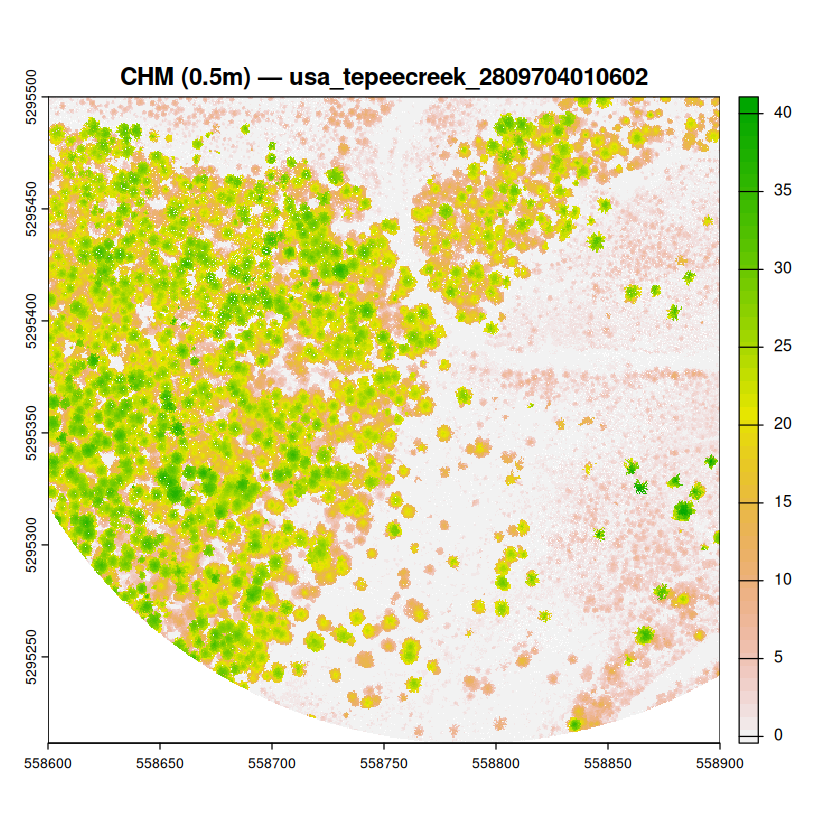

In [9]:
# ── Cell 4.2: CHM from remote MAAP GEDI CalVal COPC tile
library(lasR)
library(terra)

# Same 300x300m window as DTM
XMIN <- 558600; XMAX <- 558900
YMIN <- 5295200; YMAX <- 5295500

chm_out <- file.path(tempdir(), paste0(test_item$id, "_chm.tif"))
cat("Computing CHM from remote COPC...\nOutput:", chm_out, "\n\n")

t0 <- proc.time()
ground_tri <- triangulate(filter = keep_ground())

pipeline_chm <- reader_las_rectangles(
    xmin = XMIN, ymin = YMIN,
    xmax = XMAX, ymax = YMAX,
    copc_depth = NULL
  ) +
  ground_tri +
  transform_with(ground_tri) +
  lasR::rasterize(res = 0.5, method = "max", ofile = chm_out)

exec(pipeline_chm, on = TEST_URI)
cat(sprintf("\nCHM completed in %.1fs\n", (proc.time() - t0)["elapsed"]))

if (file.exists(chm_out)) {
  chm <- terra::rast(chm_out)
  chm <- terra::crop(chm, terra::ext(XMIN, XMAX, YMIN, YMAX))
  print(chm)
  terra::plot(chm,
              main   = paste0("CHM (0.5m) — ", test_item$id),
              col    = rev(terrain.colors(50)),
              axes   = TRUE,
              legend = TRUE)
}

## Multi-File Catalogue from STAC Results

Test passing a vector of remote VSI URIs to `exec()` — the COPC cataloguing pattern.

In [10]:
# ── Multi-file catalogue — process multiple remote COPC tiles
# Demonstrates lasR can iterate over a list of remote VSI URIs
# exactly as it would with a local file catalogue

test_uris <- ALL_URIS[1:min(3, length(ALL_URIS))]
cat(sprintf("Processing %d remote COPC tiles...\n", length(test_uris)))

t0 <- proc.time()
pipeline_cat <- reader_las(copc_depth = 2L) + summarise()  # low-res for speed

results_cat <- lapply(seq_along(test_uris), function(i) {
  u <- test_uris[i]
  cat(sprintf("  [%d/%d] %s\n", i, length(test_uris), basename(u)))
  tryCatch(
    exec(pipeline_cat, on = u),
    error = function(e) { cat("    ERROR:", conditionMessage(e), "\n"); NULL }
  )
})

cat(sprintf("\nCatalogue processing done in %.1fs\n", (proc.time() - t0)["elapsed"]))
cat("\n── Per-tile Summary (depth=2) ──\n")
for (i in seq_along(results_cat)) {
  r <- results_cat[[i]]
  if (!is.null(r)) {
    cat(sprintf("  %-50s %s pts\n",
                item_info[[i]]$id,
                format(r$npoints, big.mark=",")))
  }
}

Processing 3 remote COPC tiles...
  [1/3] usa_tepeecreek_2809704010602.copc.laz
  [2/3] usa_tepeecreek_2809702010602.copc.laz
  [3/3] usa_tepeecreek_2809700010602.copc.laz

Catalogue processing done in 6.6s

── Per-tile Summary (depth=2) ──
  usa_tepeecreek_2809704010602                       1,509,730 pts
  usa_tepeecreek_2809702010602                       1,619,214 pts
  usa_tepeecreek_2809700010602                       1,438,897 pts


In [11]:
# ── Diagnostics: environment snapshot for bug reports
cat("============================================================\n")
cat("lasR COPC/VSI Diagnostics — MAAP GEDI CalVal Dataset\n")
cat("============================================================\n")
cat("Timestamp:    ", format(Sys.time()), "\n")
cat("R version:    ", R.version$version.string, "\n")
cat("lasR version: ", as.character(packageVersion("lasR")), "\n")
cat("Platform:     ", R.version$platform, "\n")
cat("GDAL version: ", system("gdal-config --version", intern = TRUE), "\n")
cat("terra version:", as.character(packageVersion("terra")), "\n")
cat("sf version:   ", as.character(packageVersion("sf")), "\n")
cat("rstac version:", as.character(packageVersion("rstac")), "\n")
cat("\nVSI ENV:\n")
for (v in c("AWS_NO_SIGN_REQUEST", "GDAL_HTTP_MERGE_CONSECUTIVE_RANGES",
            "CPL_VSIL_CURL_CHUNK_SIZE", "GDAL_HTTP_TIMEOUT")) {
  cat(sprintf("  %-40s = %s\n", v, Sys.getenv(v, "(not set)")))
}
cat("\nTest item:  ", test_item$id, "\n")
cat("Test URI:   ", TEST_URI,      "\n")
cat("TILE_EPSG:  ", TILE_EPSG,     "\n")
cat("============================================================\n")

lasR COPC/VSI Diagnostics — MAAP GEDI CalVal Dataset
Timestamp:     2026-04-16 16:45:26 
R version:     R version 4.5.1 (2025-06-13) 
lasR version:  0.20.0 
Platform:      x86_64-pc-linux-gnu 
GDAL version:  3.10.2 
terra version: 1.8.70 
sf version:    1.0.21 
rstac version: 1.0.1 

VSI ENV:
  AWS_NO_SIGN_REQUEST                      = YES
  GDAL_HTTP_MERGE_CONSECUTIVE_RANGES       = YES
  CPL_VSIL_CURL_CHUNK_SIZE                 = 1048576
  GDAL_HTTP_TIMEOUT                        = 120

Test item:   usa_tepeecreek_2809704010602 
Test URI:    /vsis3/nasa-maap-data-store/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809704010602.copc.laz 
TILE_EPSG:   3741 
